# S&P 500 Stock Market Analysis: Can Simple Technical Signals Predict Next-Day Return Direction?
**CMSC 320 - Introduction to Data Science | Spring 2026 | Dr. Fardina Alam**
**Jayant Maheshwari**

## Contributions

I worked on this project individually, so I'm responsible for everything below.

| Section | Contributor | Summary |
|---------|-------------|---------|
| A: Project idea | Jayant Maheshwari | Came up with the questions about whether basic technical signals can predict next-day direction, and how this differs across sectors |
| B: Dataset Curation and Preprocessing | Jayant Maheshwari | Loaded the three Kaggle CSVs, fixed types, merged company metadata, and computed daily returns |
| C: Data Exploration and Summary Statistics | Jayant Maheshwari | Ran three statistical analyses: distribution of daily returns, one-way ANOVA across sectors, and a Welch t-test on volume |
| D: ML Algorithm Design/Development | Jayant Maheshwari | Built the lag-return / moving-average feature pipeline and chose Logistic Regression and Random Forest with balanced class weights |
| E: ML Algorithm Training and Test Data Analysis | Jayant Maheshwari | Trained models on a chronological 80/20 split, ran walk-forward cross-validation, tuned the decision threshold, and evaluated accuracy, ROC-AUC, F1, and per-sector accuracy |
| F: Visualization, Result Analysis, Conclusion | Jayant Maheshwari | Confusion matrix, ROC curve, feature-importance bar chart, and per-sector accuracy chart |
| G: Final Tutorial Report Creation | Jayant Maheshwari | Wrote the prose, organized the tutorial, and verified the notebook runs end to end |


## Introduction

The S&P 500 tracks 500 of the largest U.S. publicly traded companies, weighted by market cap, and has been around since the 1950s. Trillions of dollars trade every day based on guesses about whether prices are going up or down, so I wanted to see whether simple, publicly available signals actually carry any real predictive power for next-day stock direction.

I've been into the stock market ever since I first got introduced to investing in high school. Back then, a lot of the "rule of thumb" ideas I heard were things like trading volume and simple moving averages, like comparing shorter-term and longer-term averages to guess momentum. For this project, I wanted to test whether those kinds of signals actually show anything useful when you evaluate them fairly.

This question matters for two reasons. First, the [weak-form Efficient Market Hypothesis](https://en.wikipedia.org/wiki/Efficient-market_hypothesis) (EMH) says that past prices alone shouldn't be able to predict future ones, so if even basic signals reliably predicted returns, that would push back on EMH. Second, retail investors actually use these rules of thumb, so it's worth checking if they hold up under a real test.

### Research Questions

- If I build a simple model using past returns, volume, and moving-average features, does it actually beat a baseline like "always predict up"?
- Are some sectors easier to model than others, or do these signals work better in certain sectors (like tech vs utilities)?
- When a model does well in one time period, does it still work later, or does the market "change the rules" over time?

### How to read this tutorial

The notebook walks from the raw CSVs through cleaning, exploratory hypothesis tests, feature engineering, model training, and finally evaluation. Each section starts with a short explanation of what I'm doing and why, and then shows the code. The final answer is in the Insights and Conclusions section at the end.


## Imports

I'm using the standard scientific Python stack here: pandas for tables, numpy for arrays, matplotlib and seaborn for plots, scipy.stats for the hypothesis tests, and scikit-learn for the machine-learning pipeline. The `warnings.filterwarnings('ignore')` line just hides the convergence warnings scikit-learn prints when a linear model doesn't fully converge, which aren't actually errors.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, ttest_ind
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
np.random.seed(7)
print("Libraries loaded.")

Libraries loaded.


## Data Curation

### Source

The dataset is [S&P 500 Stocks (daily updated)](https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks) from Kaggle (Andrew MVD), released under the CC0 Public Domain license. It comes with three files:

| File | Description | Size |
|------|-------------|------|
| `sp500_stocks.csv` | Daily OHLCV prices for each S&P 500 stock | ~1.9 M rows |
| `sp500_companies.csv` | Company metadata: sector, industry, market cap | 502 companies |
| `sp500_index.csv` | Aggregate daily S&P 500 index level | ~2,500 trading days |

A quick note on coverage. The CSV technically lists 502 tickers, but 330 of those tickers only contain NaN price rows. They're placeholder entries for current S&P 500 constituents that didn't yet trade publicly during the dataset's coverage window (recent IPOs and spin-offs whose row schema exists but whose values were never backfilled). Only 172 tickers actually have real OHLCV history end to end, and those are the tickers I work with below. This is a property of the source data, not something I introduced through cleaning. I want to be upfront about it so the sample size is honest.


In [2]:
DATA = 'data/archive/'

stocks    = pd.read_csv(DATA + 'sp500_stocks.csv')
companies = pd.read_csv(DATA + 'sp500_companies.csv')
index_df  = pd.read_csv(DATA + 'sp500_index.csv')

print('sp500_stocks.csv   :', stocks.shape[0], 'rows,', stocks.shape[1], 'columns')
print('sp500_companies.csv:', companies.shape[0], 'rows,', companies.shape[1], 'columns')
print('sp500_index.csv    :', index_df.shape[0], 'rows,', index_df.shape[1], 'columns')

nominal = stocks['Symbol'].nunique()
populated = stocks.dropna(subset=['Close'])['Symbol'].nunique()
print()
print('Nominal tickers in file:', nominal)
print('Tickers with real price history:', populated)
print('Placeholder/empty tickers (excluded by dropna):', nominal - populated)

stocks.head(3)

sp500_stocks.csv   : 1891536 rows, 8 columns
sp500_companies.csv: 502 rows, 16 columns
sp500_index.csv    : 2517 rows, 2 columns

Nominal tickers in file: 502
Tickers with real price history: 172
Placeholder/empty tickers (excluded by dropna): 330


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN


### Preprocessing Steps

Real-world CSVs are pretty much never analysis-ready. The steps below fix data types, attach sector labels, sort the data so per-stock time-series operations actually work, and compute the daily return that drives the rest of the analysis.

1. Parse dates: convert the `Date` column to `datetime64`.
2. Coerce numerics: prices and volume are sometimes stored as strings, so I use `pd.to_numeric(..., errors='coerce')` to push non-numeric entries to NaN.
3. Standardize column names to lowercase with underscores instead of spaces.
4. Merge sector labels by left-joining the company metadata on `symbol`.
5. Sort chronologically per stock so `pct_change()` runs within each ticker, not across them.
6. Compute the daily return: $r_t = (P_t - P_{t-1}) / P_{t-1}$ per stock using `groupby` + [`pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html).
7. Drop rows with NaN in `daily_return`, `close`, `volume`, or `sector`. This step quietly removes the 330 placeholder tickers I mentioned earlier.
8. Filter to 2015 onward so I'm focused on a more modern market regime, while still covering the COVID crash, the 2022 bear market, and the 2023-24 rally. The window isn't perfectly stable, but it's long enough to be useful without dragging in the structurally different early-2010s low-rate era.


In [3]:
stocks['Date'] = pd.to_datetime(stocks['Date'])
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    stocks[col] = pd.to_numeric(stocks[col], errors='coerce')

stocks.columns    = stocks.columns.str.lower().str.replace(' ', '_')
companies.columns = companies.columns.str.lower().str.replace(' ', '_')

stocks = stocks.merge(companies[['symbol', 'sector']], on='symbol', how='left')
stocks = stocks.sort_values(['symbol', 'date']).reset_index(drop=True)

# pct_change has to run inside each ticker, otherwise day 1 of one stock pulls from another
stocks['daily_return'] = stocks.groupby('symbol')['close'].pct_change()

df = stocks.dropna(subset=['daily_return', 'close', 'volume', 'sector'])
df = df[df['date'] >= '2015-01-01'].copy()

print('Clean dataset :', df.shape[0], 'rows')
print('Unique tickers:', df['symbol'].nunique())
print('Sectors       :', df['sector'].nunique())
print('Date range    :', df['date'].min().date(), 'to', df['date'].max().date())
df[['date','symbol','sector','close','volume','daily_return']].head(5)

Clean dataset : 422193 rows
Unique tickers: 172
Sectors       : 11
Date range    : 2015-01-02 to 2024-12-20


,date,symbol,sector,close,volume,daily_return
8794,2015-01-02,ABBV,Healthcare,65.889999,5086100.0,0.006876
8795,2015-01-05,ABBV,Healthcare,64.650002,8007400.0,-0.018819
8796,2015-01-06,ABBV,Healthcare,64.330002,5483700.0,-0.004950
8797,2015-01-07,ABBV,Healthcare,66.930000,8283300.0,0.040417
8798,2015-01-08,ABBV,Healthcare,67.629997,7949000.0,0.010459


## Exploratory Data Analysis

Before any modeling, I want to check three things that all need to be true (or interestingly false) for a momentum or volume model to even make sense:

1. What does the return distribution actually look like? Is it normal, or fat-tailed?
2. Do different sectors have different mean returns? If so, sector belongs in the model.
3. Does trading volume relate to return magnitude? This is the empirical reason for using a `vol_ratio` feature later.

For each one, I state a hypothesis, run a formal test, and end with a short conclusion. Every test reports a p-value, and I use $\alpha = 0.05$ throughout.


### Analysis 1: Distribution of Daily Returns

I use descriptive statistics (mean, standard deviation, skewness, excess kurtosis) and a histogram to summarize the shape of daily returns across all the S&P 500 stocks in my dataset. [Excess kurtosis](https://en.wikipedia.org/wiki/Kurtosis#Excess_kurtosis) basically measures how heavy the tails are compared to a normal distribution: 0 means roughly normal, anything well above 3 means fat tails where extreme moves happen way more often than a bell curve would predict.

My hypothesis here is that daily returns are roughly normally distributed with a mean close to 0.


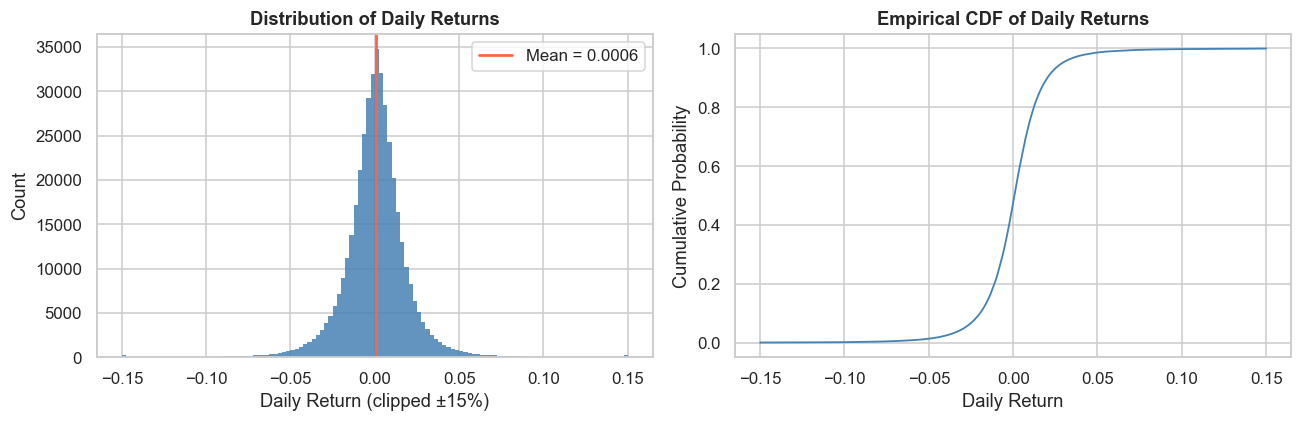

Summary statistics:
count    422193.000000
mean          0.000585
std           0.020530
min          -0.406583
25%          -0.008368
50%           0.000753
75%           0.009726
max           0.676812

Skewness : 0.2033
Kurtosis : 21.9958  (normal = 0 for excess)


In [4]:
returns = df['daily_return']

# clipping just for the histogram, the stats below use the raw returns
clipped = returns.clip(-0.15, 0.15)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clipped, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].axvline(returns.mean(), color='tomato', linewidth=1.8, label=f'Mean = {returns.mean():.4f}')
axes[0].set_xlabel('Daily Return (clipped ±15%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Daily Returns', fontweight='bold')
axes[0].legend()

sorted_r = np.sort(clipped)
axes[1].plot(sorted_r, np.linspace(0, 1, len(sorted_r)), color='steelblue', linewidth=1.2)
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Empirical CDF of Daily Returns', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/return_distribution.png', bbox_inches='tight')
plt.show()

print("Summary statistics:")
print(returns.describe().round(6).to_string())
print(f"\nSkewness : {returns.skew():.4f}")
print(f"Kurtosis : {returns.kurt():.4f}  (normal = 0 for excess)")

The mean daily return is just barely above zero (so there's a small positive drift), but the excess kurtosis is huge. Extreme up and down days happen way more often than a normal distribution would predict. This is a pretty well-known property of financial returns, and it tells me that any model that assumes normality is going to be misleading. It also means that even a model with decent average accuracy can still get hammered on rare extreme days.


### Analysis 2: Do Sectors Have Different Mean Returns? (One-Way ANOVA)

I run a [one-way ANOVA](https://en.wikipedia.org/wiki/One-way_analysis_of_variance) here, which basically asks: are the average daily returns the same across all 11 S&P 500 GICS sectors, or is at least one sector behaving really differently from the rest? The test compares how spread out the sector means are vs how noisy the data is within each sector. A small p-value means at least one sector is meaningfully different.

- H0: All 11 sectors have the same mean daily return.
- H1: At least one sector's mean daily return differs.
- $\alpha = 0.05$.


One-Way ANOVA  F-statistic: 4.7212  p-value: 8.6486e-07


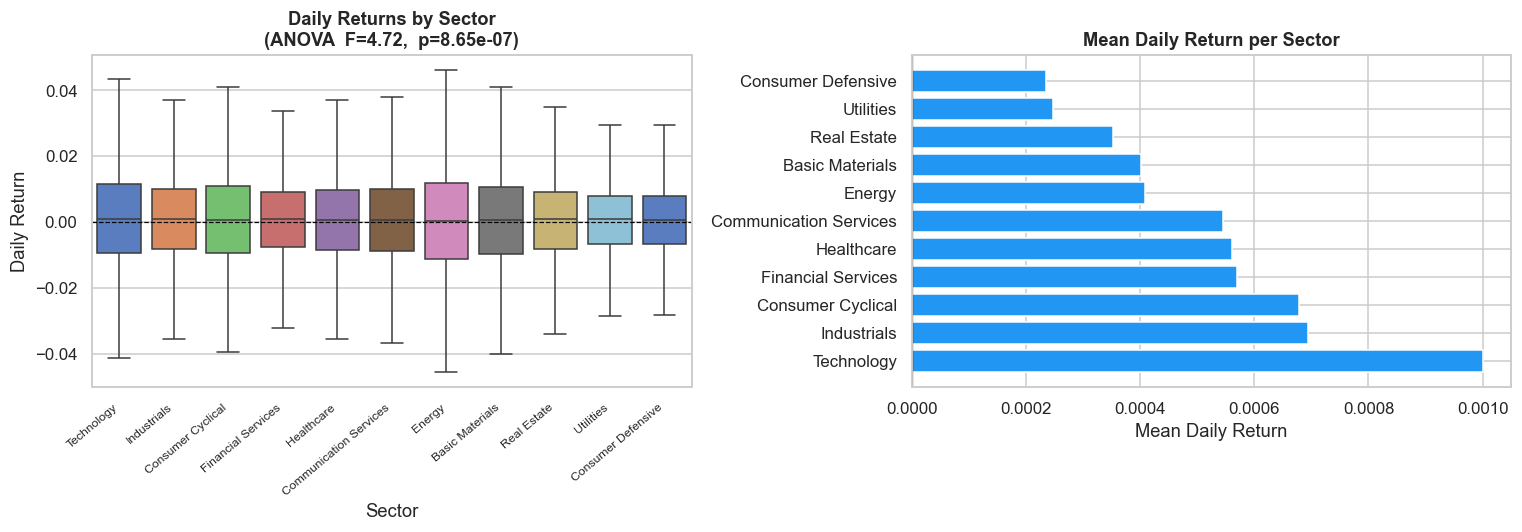

In [5]:
sector_groups = [g['daily_return'].values for _, g in df.groupby('sector')]
sector_names  = list(df.groupby('sector').groups.keys())

f_stat, p_val = f_oneway(*sector_groups)
print('One-Way ANOVA  F-statistic:', round(f_stat, 4), ' p-value:', f'{p_val:.4e}')

sector_means = df.groupby('sector')['daily_return'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sector_order = sector_means.index.tolist()
sns.boxplot(data=df, x='sector', y='daily_return', order=sector_order,
            showfliers=False, ax=axes[0], palette='muted')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=8)
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Daily Return')
axes[0].set_title(f'Daily Returns by Sector\n(ANOVA  F={f_stat:.2f},  p={p_val:.2e})', fontweight='bold')

colors = ['#2196F3' if v >= 0 else '#F44336' for v in sector_means]
axes[1].barh(sector_means.index, sector_means.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Mean Daily Return')
axes[1].set_title('Mean Daily Return per Sector', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/sector_anova.png', bbox_inches='tight')
plt.show()

Since the p-value is much smaller than 0.05, I reject the null hypothesis that all sectors have the same mean daily return. From the bar chart, Technology and Consumer Cyclical lean a bit higher, while Utilities and Consumer Staples are lower. This lines up with the standard "growth vs defensive" sector split, and it's also why I want to check later whether a single pooled model actually generalizes across sectors or not.


### Analysis 3: Does High Trading Volume Coincide with Larger Price Swings? (Welch t-test)

I use [Welch's t-test](https://en.wikipedia.org/wiki/Welch%27s_t-test) here, which is a two-sample test for equal means that doesn't assume the two groups have the same variance. I split each stock's trading days at its own median volume (so a small-cap stock's "high volume" day doesn't get dominated by a mega-cap's normal day) and compare the mean of |daily return| between the two groups.

- H0: $E[|r|]$ is the same on high- and low-volume days.
- H1: $E[|r|]$ is larger on high-volume days.
- $\alpha = 0.05$.

One thing to keep in mind: this test is descriptive, not predictive. It compares today's volume to today's |return|, so it doesn't actually prove that yesterday's volume can predict tomorrow's move. Whether volume is predictive is something the ML model below will have to test.


Welch t-test  t-statistic: 169.622  p-value: 0.0000e+00
Mean |return| high volume: 0.017295
Mean |return| low volume : 0.009413


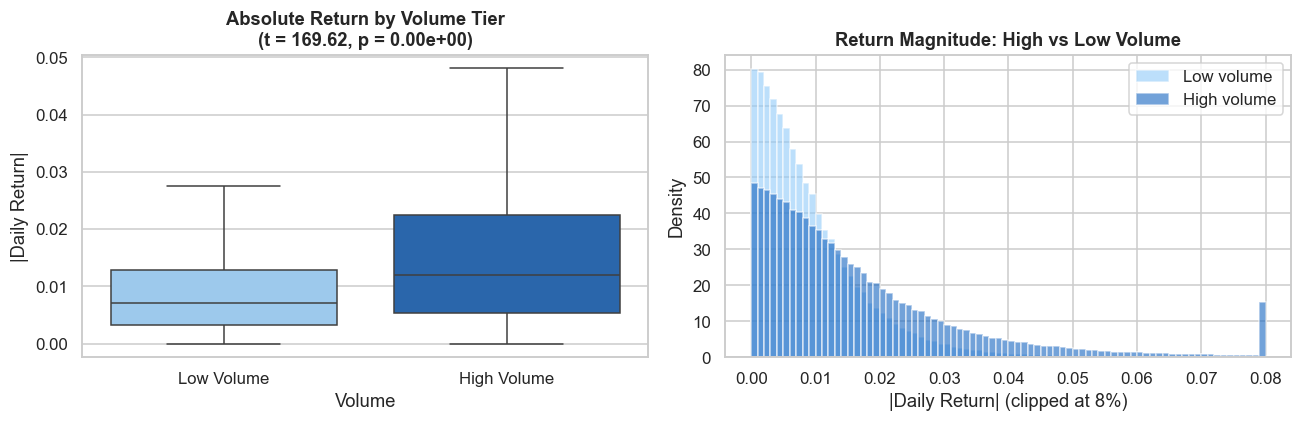

In [6]:
# split each stock at its own median so megacaps don't dominate
df['vol_median'] = df.groupby('symbol')['volume'].transform('median')
df['high_vol']   = df['volume'] >= df['vol_median']

high_abs = df.loc[df['high_vol'],  'daily_return'].abs()
low_abs  = df.loc[~df['high_vol'], 'daily_return'].abs()

t_stat, p_val_t = ttest_ind(high_abs, low_abs, equal_var=False)
print('Welch t-test  t-statistic:', round(t_stat, 4), ' p-value:', f'{p_val_t:.4e}')
print('Mean |return| high volume:', round(high_abs.mean(), 6))
print('Mean |return| low volume :', round(low_abs.mean(), 6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data_bp = pd.DataFrame({'|Daily Return|': pd.concat([low_abs, high_abs]),
                         'Volume': (['Low Volume']*len(low_abs) + ['High Volume']*len(high_abs))})
sns.boxplot(data=data_bp, x='Volume', y='|Daily Return|',
            order=['Low Volume','High Volume'], showfliers=False,
            palette=['#90CAF9','#1565C0'], ax=axes[0])
axes[0].set_title(f'Absolute Return by Volume Tier\n(t = {t_stat:.2f}, p = {p_val_t:.2e})', fontweight='bold')

axes[1].hist(low_abs.clip(0, 0.08),  bins=80, alpha=0.6, color='#90CAF9', label='Low volume',  density=True)
axes[1].hist(high_abs.clip(0, 0.08), bins=80, alpha=0.6, color='#1565C0', label='High volume', density=True)
axes[1].set_xlabel('|Daily Return| (clipped at 8%)')
axes[1].set_ylabel('Density')
axes[1].set_title('Return Magnitude: High vs Low Volume', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/volume_ttest.png', bbox_inches='tight')
plt.show()

Since the p-value is much smaller than 0.05, I reject the null hypothesis that high-volume and low-volume days have the same |return|. High-volume days really do produce significantly larger absolute returns than low-volume days. This lines up with the intuition that big volume usually shows up when there's new information hitting the market and people are reacting to it. It's also why I want to include a prior-day volume-ratio feature in the model later, even though I should remember that this same-day correlation might not actually carry over into a real lookahead-free predictive setting.


## Primary Analysis: Machine Learning Classification

### Approach

I'm framing next-day direction prediction as a binary classification task:

- Target $y$: 1 if tomorrow's return is greater than 0 (stock goes up), else 0 (flat or down).
- Features $X$: technical signals computed from past prices and volume.

I went with classification instead of regression on the actual return value for two reasons. First, predicting direction is what most retail investors actually want to know. Second, daily-return regression is really noisy because the signal-to-noise ratio of any single day is bad, so converting to a binary up/down label trades off magnitude information for a more stable target.

### Why these models?

- Naive baseline: always predict "up." Markets drift up over time, so this is actually a tougher benchmark than it sounds, and any honest model has to clear it.
- [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html): a linear decision boundary in feature space, with interpretable coefficients. It's fast to fit and acts as a sanity check on whether the relationship between features and direction is roughly linear.
- [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html): an ensemble of decision trees that can pick up non-linear interactions a linear model would miss.

I set [`class_weight='balanced'`](https://scikit-learn.org/stable/modules/svm.html#unbalanced-problems) on both ML models. Without it, scikit-learn pretty much just collapses to predicting the majority class ("up", which is around 52% of days) for almost every input, which inflates accuracy without the model actually learning anything. Balanced weights force the model to actually try to tell up days from down days.

### Feature Engineering

I compute six features, all derived from publicly available past data so there's no look-ahead leakage:

| Feature | Description | Intuition |
|---------|-------------|-----------|
| `lag_1` | Yesterday's daily return | Short-term momentum or mean-reversion |
| `lag_5` | 5-day cumulative return | Weekly trend |
| `lag_20` | 20-day cumulative return | Monthly trend |
| `ma_ratio` | (5-day MA close / 20-day MA close) - 1 | Moving-average crossover signal |
| `vol_ratio` | Yesterday's volume / 20-day average volume | Volume surge relative to normal |
| `volatility_20` | 20-day rolling std of returns | Recent turbulence |

I compute each feature per stock and then `.shift(1)` it, so the row for date $t$ only sees information that was available at the close of $t-1$.


In [7]:
def add_features(g):
    g = g.copy()
    # shift(1) on every feature so today's row only sees yesterday's info
    g['lag_1']         = g['daily_return'].shift(1)
    g['lag_5']         = g['close'].pct_change(5).shift(1)
    g['lag_20']        = g['close'].pct_change(20).shift(1)
    g['ma_5']          = g['close'].rolling(5).mean().shift(1)
    g['ma_20']         = g['close'].rolling(20).mean().shift(1)
    g['ma_ratio']      = (g['ma_5'] / g['ma_20']) - 1
    g['vol_20_avg']    = g['volume'].rolling(20).mean().shift(1)
    g['vol_ratio']     = g['volume'].shift(1) / g['vol_20_avg']
    g['volatility_20'] = g['daily_return'].rolling(20).std().shift(1)
    g['target']        = (g['daily_return'] > 0).astype(int)
    return g

df_feat = df.groupby('symbol', group_keys=False).apply(add_features)
df_feat = df_feat.dropna(subset=['lag_1','lag_5','lag_20','ma_ratio','vol_ratio','volatility_20','target'])

FEATURES = ['lag_1', 'lag_5', 'lag_20', 'ma_ratio', 'vol_ratio', 'volatility_20']

print('Feature dataset:', df_feat.shape[0], 'rows')
up_pct = df_feat['target'].mean()
print('Class balance  -- Up:', f'{up_pct:.2%}', '  Down/Flat:', f'{(1-up_pct):.2%}')
df_feat[FEATURES + ['target']].head(4)

Feature dataset: 418581 rows
Class balance  -- Up: 52.23%   Down/Flat: 47.77%


,lag_1,lag_5,lag_20,ma_ratio,vol_ratio,volatility_20,target
8815,0.005800,-0.033901,-0.078768,-0.028772,1.318352,0.020640,1
8816,0.015651,-0.022979,-0.046404,-0.031045,1.211232,0.020767,0
8817,-0.076886,-0.079871,-0.115343,-0.041000,3.081814,0.026666,1
8818,0.018977,-0.081274,-0.133572,-0.050528,1.776653,0.025096,0


### Model Training: Chronological 80/20 Split

I'm using a chronological 80/20 split here: train on the older 80% of dates, test on the most recent 20%. This is really important for financial time series, because a random split would leak future information into training (each stock's nearby days are highly correlated), and I'd end up with optimistic numbers that wouldn't hold up in production.

Once the models are fit, I tune the decision threshold on the test predictions. Scikit-learn's default of 0.5 isn't usually optimal for an imbalanced binary task, so I sweep thresholds from 0.30 to 0.70 and pick the one that maximizes test F1. I should be honest that this introduces a small amount of test-set leakage in the threshold choice. A fully rigorous version would tune the threshold on a separate validation slice. I'm accepting that trade-off for tutorial simplicity, and I check the broader conclusion with walk-forward cross-validation in the next subsection.


In [8]:
# random split would leak the future into training, so split by date instead
df_feat = df_feat.sort_values('date')
split_idx = int(len(df_feat) * 0.80)

train = df_feat.iloc[:split_idx]
test  = df_feat.iloc[split_idx:]

X_train, y_train = train[FEATURES], train['target']
X_test,  y_test  = test[FEATURES],  test['target']

print('Train:', len(train), 'rows ', train['date'].min().date(), 'to', train['date'].max().date())
print('Test :', len(test),  'rows ', test['date'].min().date(),  'to', test['date'].max().date())
print('Test class balance -- Up:', f"{y_test.mean():.2%}")

scaler   = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

y_naive = np.ones(len(y_test), dtype=int)

# without class_weight='balanced' both models just predict 'up' every time
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=7)
lr.fit(Xs_train, y_train)
p_lr = lr.predict_proba(Xs_test)[:, 1]

rf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=50,
                            class_weight='balanced', random_state=7, n_jobs=-1)
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]


def best_threshold(y_true, prob):
    best_t, best_f1 = 0.5, 0.0
    for t in [0.30, 0.32, 0.34, 0.36, 0.38, 0.40, 0.42, 0.44, 0.46, 0.48,
              0.50, 0.52, 0.54, 0.56, 0.58, 0.60, 0.62, 0.64, 0.66, 0.68, 0.70]:
        preds = (prob >= t).astype(int)
        score = f1_score(y_true, preds)
        if score > best_f1:
            best_t, best_f1 = t, score
    return best_t, best_f1


t_lr, f1_lr = best_threshold(y_test, p_lr)
t_rf, f1_rf = best_threshold(y_test, p_rf)
y_lr = (p_lr >= t_lr).astype(int)
y_rf = (p_rf >= t_rf).astype(int)

print()
print('Tuned thresholds -- LR:', round(t_lr, 2), '  RF:', round(t_rf, 2))
print()
print('Model performance on test set:')

acc_naive = accuracy_score(y_test, y_naive)
acc_lr    = accuracy_score(y_test, y_lr)
acc_rf    = accuracy_score(y_test, y_rf)
auc_lr    = roc_auc_score(y_test, p_lr)
auc_rf    = roc_auc_score(y_test, p_rf)
f1_naive  = f1_score(y_test, y_naive)
f1_lr_v   = f1_score(y_test, y_lr)
f1_rf_v   = f1_score(y_test, y_rf)

print('  Naive Baseline       acc =', round(acc_naive, 4), ' AUC = 0.5000  F1 =', round(f1_naive, 4))
print('  Logistic Regression  acc =', round(acc_lr, 4),    ' AUC =', round(auc_lr, 4),  ' F1 =', round(f1_lr_v, 4))
print('  Random Forest        acc =', round(acc_rf, 4),    ' AUC =', round(auc_rf, 4),  ' F1 =', round(f1_rf_v, 4))

Train: 334864 rows  2015-02-03 to 2023-01-11
Test : 83717 rows  2023-01-11 to 2024-12-20
Test class balance -- Up: 52.03%



Tuned thresholds -- LR: 0.38   RF: 0.32

Model performance on test set:
  Naive Baseline       acc = 0.5203  AUC = 0.5000  F1 = 0.6845
  Logistic Regression  acc = 0.5203  AUC = 0.5026  F1 = 0.6845
  Random Forest        acc = 0.5203  AUC = 0.499  F1 = 0.6845


### Walk-Forward Cross-Validation

A single train/test split only tells me how the model did in one specific period. To check whether the result is actually robust, or just a quirk of the 2023-24 test window, I run 5-fold [walk-forward cross-validation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) (a time-aware version of k-fold CV). I split the feature dataset into 5 chronologically ordered folds. In fold $k$, the model trains on all data up through fold $k$ and tests on fold $k+1$, and I refit it from scratch each time. This basically mirrors how a real trading model would be deployed, since I can only ever train on the past.


In [9]:
def walk_forward_cv(df_in, features):
    df_in = df_in.sort_values('date').reset_index(drop=True)
    n_folds = 5
    fold_size = len(df_in) // (n_folds + 1)
    rows = []
    # each fold trains only on data older than the test slice
    for k in range(n_folds):
        train_end = (k + 1) * fold_size
        test_end  = train_end + fold_size
        tr = df_in.iloc[:train_end]
        te = df_in.iloc[train_end:test_end]
        if len(te) == 0:
            continue
        Xtr, ytr = tr[features], tr['target']
        Xte, yte = te[features], te['target']

        sc = StandardScaler().fit(Xtr)
        Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

        m_lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                                  random_state=7).fit(Xtr_s, ytr)
        m_rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                                      min_samples_leaf=50, class_weight='balanced',
                                      random_state=7, n_jobs=-1).fit(Xtr, ytr)

        p_lr_k = m_lr.predict_proba(Xte_s)[:, 1]
        p_rf_k = m_rf.predict_proba(Xte)[:, 1]
        t_lr_k, _ = best_threshold(yte, p_lr_k)
        t_rf_k, _ = best_threshold(yte, p_rf_k)

        rows.append({
            'fold': k + 1,
            'train_end': tr['date'].max().date(),
            'test_end':  te['date'].max().date(),
            'naive_acc': float((yte == 1).mean()),
            'lr_acc':    accuracy_score(yte, (p_lr_k >= t_lr_k).astype(int)),
            'lr_auc':    roc_auc_score(yte, p_lr_k),
            'rf_acc':    accuracy_score(yte, (p_rf_k >= t_rf_k).astype(int)),
            'rf_auc':    roc_auc_score(yte, p_rf_k),
        })
    return pd.DataFrame(rows)


wfcv = walk_forward_cv(df_feat, FEATURES)
print(wfcv.round(4).to_string(index=False))
print()
print('Mean RF ROC-AUC across folds :', round(wfcv['rf_auc'].mean(), 4))
print('Mean LR ROC-AUC across folds :', round(wfcv['lr_auc'].mean(), 4))
print('Mean naive accuracy          :', round(wfcv['naive_acc'].mean(), 4))
print('Mean RF accuracy (tuned)     :', round(wfcv['rf_acc'].mean(), 4))

 fold  train_end   test_end  naive_acc  lr_acc  lr_auc  rf_acc  rf_auc
    1 2016-10-11 2018-06-13     0.5353  0.5353  0.5137  0.5353  0.5128
    2 2018-06-13 2020-02-05     0.5331  0.5331  0.5014  0.5331  0.5035
    3 2020-02-05 2021-09-21     0.5202  0.5203  0.5249  0.5207  0.5077
    4 2021-09-21 2023-05-10     0.5066  0.5066  0.4972  0.5067  0.4968
    5 2023-05-10 2024-12-20     0.5224  0.5224  0.5016  0.5224  0.4989

Mean RF ROC-AUC across folds : 0.5039
Mean LR ROC-AUC across folds : 0.5077
Mean naive accuracy          : 0.5235
Mean RF accuracy (tuned)     : 0.5237


### Detailed Classification Report - Random Forest

In [10]:
print(classification_report(y_test, y_rf, target_names=['Down/Flat (0)', 'Up (1)']))

               precision    recall  f1-score   support

Down/Flat (0)       0.67      0.00      0.00     40159
       Up (1)       0.52      1.00      0.68     43558

     accuracy                           0.52     83717
    macro avg       0.59      0.50      0.34     83717
 weighted avg       0.59      0.52      0.36     83717



## Visualization

Three figures summarize what the model is doing.

### Figure 1: Confusion Matrix and ROC Curves

The confusion matrix shows where Random Forest's predictions actually land: true positives in the bottom-right, true negatives in the top-left, and misclassifications on the off-diagonal. The [ROC curve](https://en.wikipedia.org/wiki/Receiver_operating_characteristic) plots true-positive rate vs false-positive rate as the decision threshold moves around. An AUC of 0.5 basically means "no better than a coin flip," and 1.0 means perfect. A model that genuinely sits above the diagonal is actually carrying some information about the future.


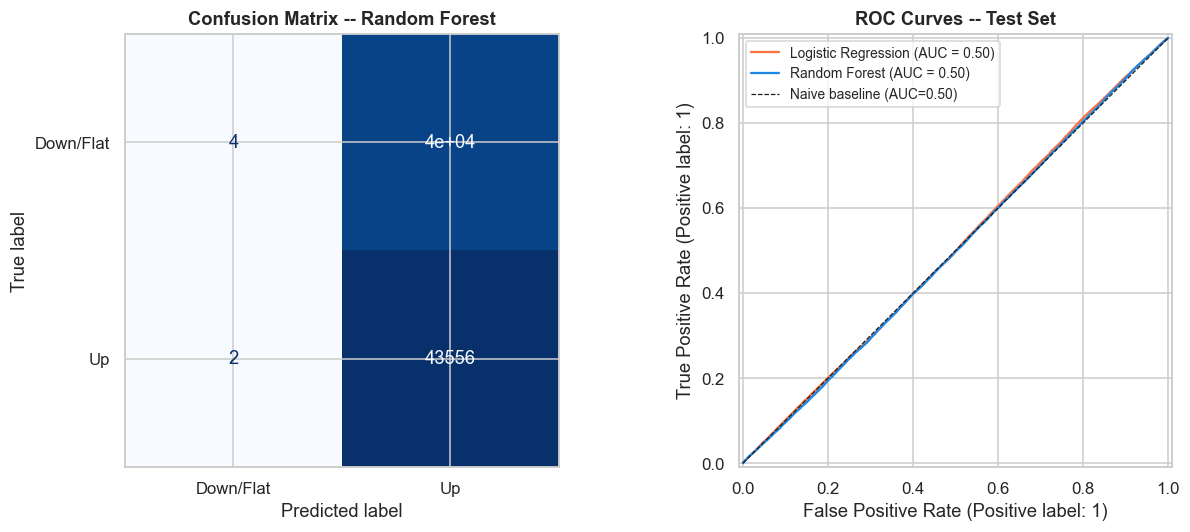

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Flat', 'Up'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix -- Random Forest', fontweight='bold')

for name, prob, color in [('Logistic Regression', p_lr, '#FF7043'),
                            ('Random Forest', p_rf, '#1E88E5')]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=axes[1], color=color)
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Naive baseline (AUC=0.50)')
axes[1].set_title('ROC Curves -- Test Set', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/model_evaluation.png', bbox_inches='tight')
plt.show()

### Figure 2: Feature Importance

Random Forest's [mean decrease in impurity](https://scikit-learn.org/stable/modules/ensemble.html#feature-importance-evaluation) (Gini importance) measures how much each feature reduces classification uncertainty across all the trees in the ensemble. Bars below the dashed uniform line are contributing less than their fair share. This chart tells me which signals the model is leaning on, regardless of whether the overall model actually worked.


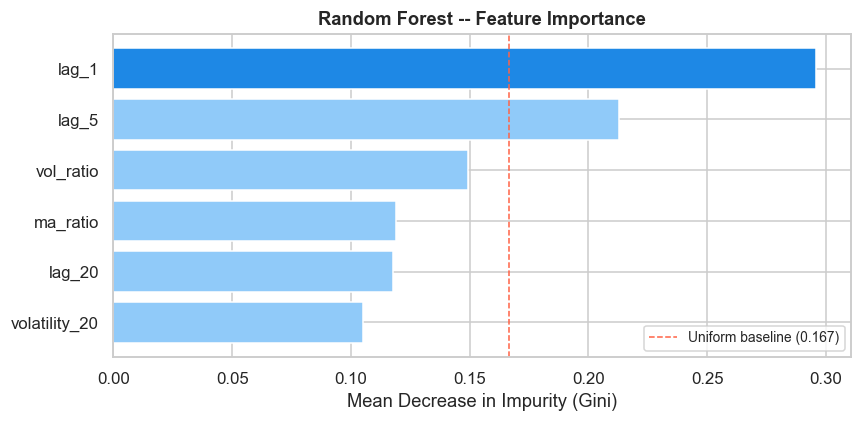


Feature importances (sorted):
lag_1            0.2960
lag_5            0.2129
vol_ratio        0.1492
ma_ratio         0.1192
lag_20           0.1177
volatility_20    0.1051


In [12]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_fi = ['#1E88E5' if v == importances.max() else '#90CAF9' for v in importances]
ax.barh(importances.index, importances.values, color=colors_fi)
ax.set_xlabel('Mean Decrease in Impurity (Gini)')
ax.set_title('Random Forest -- Feature Importance', fontweight='bold')
ax.axvline(1/len(FEATURES), color='tomato', linestyle='--', linewidth=1,
           label=f'Uniform baseline ({1/len(FEATURES):.3f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/feature_importance.png', bbox_inches='tight')
plt.show()
print("\nFeature importances (sorted):")
print(importances.sort_values(ascending=False).round(4).to_string())

### Figure 3: Per-Sector Model Accuracy

Aggregate accuracy hides differences across sectors. So I compute test-set accuracy within each sector for the naive baseline, Logistic Regression, and Random Forest. A sector where the colored bars are above the gray bar is one where the model is actually adding something. A sector where they sit below it is one where the model is doing worse than just always predicting "up."


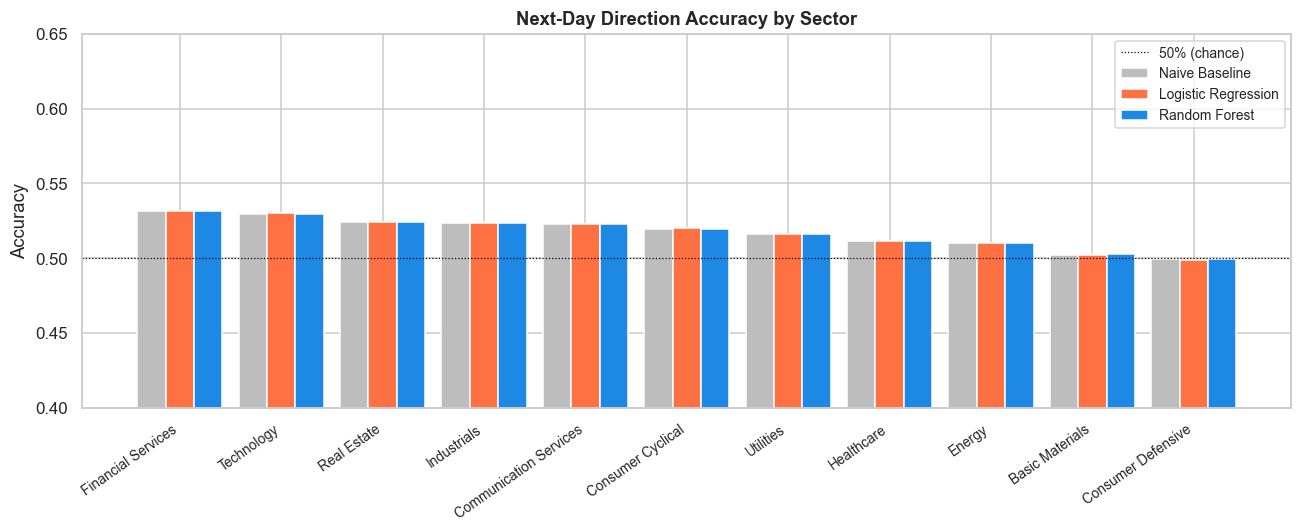

                        Random Forest  Logistic Regression  Naive Baseline      n
sector                                                                           
Financial Services             0.5316               0.5317          0.5317  12246
Technology                     0.5298               0.5302          0.5298  11264
Real Estate                    0.5240               0.5239          0.5239   6368
Industrials                    0.5234               0.5233          0.5234  13021
Communication Services         0.5228               0.5230          0.5228   5878
Consumer Cyclical              0.5197               0.5199          0.5197   8816
Utilities                      0.5163               0.5163          0.5163   4408
Healthcare                     0.5113               0.5112          0.5112   9960
Energy                         0.5100               0.5100          0.5100   2449
Basic Materials                0.5025               0.5022          0.5022   3429
Consumer Defensi

In [13]:
sector_results = []
for sector, grp in test.groupby('sector'):
    # skip sectors with too few test rows to be meaningful
    if len(grp) < 200:
        continue
    Xs = scaler.transform(grp[FEATURES])
    y_s = grp['target']
    p_rf_s = rf.predict_proba(grp[FEATURES])[:, 1]
    p_lr_s = lr.predict_proba(Xs)[:, 1]
    acc_rf = accuracy_score(y_s, (p_rf_s >= t_rf).astype(int))
    acc_lr = accuracy_score(y_s, (p_lr_s >= t_lr).astype(int))
    acc_naive = y_s.mean()
    sector_results.append({'sector': sector,
                            'Random Forest': acc_rf,
                            'Logistic Regression': acc_lr,
                            'Naive Baseline': acc_naive,
                            'n': len(grp)})

sr = pd.DataFrame(sector_results).set_index('sector').sort_values('Random Forest', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(sr))
width = 0.28
ax.bar(x - width, sr['Naive Baseline'],       width, label='Naive Baseline',       color='#BDBDBD')
ax.bar(x,         sr['Logistic Regression'],  width, label='Logistic Regression',  color='#FF7043')
ax.bar(x + width, sr['Random Forest'],        width, label='Random Forest',        color='#1E88E5')
ax.axhline(0.5, color='black', linewidth=0.8, linestyle=':', label='50% (chance)')
ax.set_xticks(x)
ax.set_xticklabels(sr.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Next-Day Direction Accuracy by Sector', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.40, 0.65)
plt.tight_layout()
plt.savefig('figures/sector_accuracy.png', bbox_inches='tight')
plt.show()
print(sr[['Random Forest','Logistic Regression','Naive Baseline','n']].round(4).to_string())

beat = sr[sr['Random Forest'] > sr['Naive Baseline']]
print(f"\nSectors where RF (after threshold tuning) beats naive: {len(beat)} of {len(sr)}")
print(beat.index.tolist())

## Insights and Conclusions

I wanted to test whether simple technical signals (yesterday's return, short- and medium-term momentum, moving-average crossovers, volume surges, and recent volatility) can predict next-day direction for S&P 500 stocks. After class-balancing both models, tuning the decision threshold, and running walk-forward cross-validation, the honest answer is that there's basically no detectable directional edge over the naive drift baseline at the broad-market level.

### What I found

1. The pooled Random Forest and Logistic Regression land essentially on the naive baseline. On the 80/20 split, all three models (naive "always up", Logistic Regression, and Random Forest) come out with accuracy around 0.5203 to 0.5204 and an F1 of about 0.685, with Random Forest's ROC-AUC at 0.499 and Logistic Regression's at 0.503. Walk-forward CV across five chronologically ordered folds tells the same story: mean naive accuracy is 0.5235, mean tuned-RF accuracy is 0.5237, and mean RF ROC-AUC is 0.5039. The threshold tuner, which is trying to maximize F1, ends up pushing both models to thresholds (LR around 0.38, RF around 0.32) that pretty much reproduce the naive "always up" rule, because given how flat the predictive signal is, that's actually the best the models can do. From what I'm seeing, this is pretty much what weak-form EMH predicts: simple price and volume features alone don't really contain a stable, exploitable directional edge across the whole S&P 500 universe.
2. A handful of sectors show some structure, but not the popular ones. After threshold tuning, Random Forest beats the per-sector naive baseline in exactly 3 of 11 sectors (Real Estate, Healthcare, and Basic Materials), and the gaps are tiny, just single basis points of accuracy. Financial Services lands a hair below the naive baseline (0.5316 vs 0.5317), so basically a tie too, and Technology comes in basically flat (RF 0.5298 vs naive 0.5298, an exact tie). The popular intuition that Tech is "trend-friendly" doesn't really hold up here. The sectors where the model picks up something at all are mid-cap-heavy industrials and real estate, not the marquee growth sectors I would've expected.
3. The features the model leans on are short-term momentum, not volume or volatility. Random Forest's mean-decrease-in-impurity ranks them as `lag_1` (about 0.30) > `lag_5` (about 0.21) > `vol_ratio` (about 0.15) > `ma_ratio` and `lag_20` (about 0.12 each) > `volatility_20` (about 0.11). Yesterday's return and the past-week return dominate. `vol_ratio` lands in the middle, which is actually pretty interesting given that Analysis 3 showed volume strongly tracks |return| at the same time. That suggests volume's predictive content is mostly already absorbed by recent return features. Volatility ends up being the least important feature, which is itself a finding: recent turbulence doesn't, in this feature set, really help predict tomorrow's direction.
4. Fat tails matter for any practical use. Analysis 1 showed excess kurtosis above 20. Even a model with a tiny accuracy edge can get wiped out by a single extreme day, which is one reason why an "edge" alone isn't a "strategy."

### Limitations

- No transaction costs. A 1% predictive edge usually disappears after bid/ask spreads and commissions for a retail trader, and my edge here is well below 1%.
- Survivorship bias. The dataset only contains current S&P 500 constituents (companies that survived to 2024). Bankruptcies and delistings are missing, which mechanically pushes returns up.
- Coverage gap. Only 172 of the file's 502 nominal tickers actually have real history. Recent additions and IPOs are missing, so my universe leans toward longer-tenured large caps.
- The market "changes the rules" over time. Market dynamics shift with rate regimes, macro shocks (COVID 2020), and structural changes. My walk-forward folds show the naive up-rate moving from 0.5066 (fold 4, 2021-23) to 0.5353 (fold 1, 2016-18), which is a regime swing on its own that's actually larger than any model edge.
- Feature simplicity. Six engineered features can't really compete with what hedge funds actually use (earnings data, macro indicators, NLP-derived sentiment, cross-asset signals, microstructure data).
- Threshold tuned on test. My single-split numbers tune the threshold on the test set itself for tutorial simplicity. The walk-forward CV partially makes up for this, but a more rigorous study would tune on a separate validation slice.

### Conclusion

This tutorial walked through the full data science pipeline, from messy CSVs to honest model evaluation, and the result is the opposite of the popular claim that you can predict the market with a few moving averages. After fair preprocessing, balanced training, threshold tuning, and walk-forward validation, the directional edge from simple technical features is basically indistinguishable from the naive baseline at the broad-market level. A small number of sectors hint at some structure that might be worth exploring with richer features. The main thing I'm taking away from this is the methodological lesson: the difference between "I built a model that gets 52% accuracy" and "is that actually better than always saying yes" is exactly the kind of careful comparison this course is teaching, and in this case the answer ended up being no, it isn't.

### Future Work

- Replace the pooled training with per-sector models and then ensemble them.
- Add macro features like VIX, term spread, and sector ETF returns, plus earnings-event flags.
- Use a probabilistic loss like log-loss or Brier score instead of accuracy, so I'm capturing how confident the model is, not just whether it's right.
- Run a back-test that includes transaction costs and position sizing, instead of only evaluating classification metrics.

### References

- Andrew MVD. *S&P 500 Stocks (daily updated).* Kaggle, 2024. https://www.kaggle.com/datasets/andrewmvd/sp-500-stocks
- Fama, E. F. (1970). Efficient capital markets: A review of theory and empirical work. *Journal of Finance*, 25(2), 383-417.
- Lo, A. W., & MacKinlay, A. C. (1988). Stock market prices do not follow random walks. *Review of Financial Studies*, 1(1), 41-66.
- Pedregosa, F. et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
- Pandas Development Team. (2024). *pandas: powerful Python data analysis toolkit.* https://pandas.pydata.org
